<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/examen_optimizador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##################################################
##                                              ##
##                    EXAMEN                    ##
##    Pronósticos en la Cadena de Suministro    ##
##                                              ##
##                                              ##
##  Saúl Roberto Morales Velázquez              ##
##  1856691                                     ##
##                                              ##
##################################################

#**Instalación de librerías adicionales**

In [ ]:
!pip install --q prophet

# **Librerías**

In [ ]:
from google.colab import auth, drive, files # Librerías de Google Colab; «auth» permite autenticarse con la cuenta de Google, «drive» permite acceder al contenido de Google Drive, «file» permite interactuar con los archivos generados.
from prophet import Prophet as ph # Prophet de Meta (Facebook)
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
import matplotlib.pyplot as plt # Librería que permite generar gráficas.
import pandas as pd # Librería que permite la manipulación de dataframes.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.
from sklearn.metrics import mean_absolute_percentage_error as MAPE # Métricas de evaluación.

from itertools import product
import json

# **Data frame**

In [ ]:
drive.mount("/content/drive", force_remount=True) # Monta Google Drive.
wd = "/content/drive/MyDrive/Forecast_FIME/examen/" # Variable que establece el directorio de trabajo (working directory).

df_main = pd.read_csv(wd + "thelook_ecommerce.csv") # Archivo donde se encuentra la información sin transformar.
df_main["created_at"] = pd.to_datetime(df_main["created_at"], format="mixed").dt.date # Convierte el formato de fecha UTC en ISO.

df_filtered = df_main[df_main["status"] == "Processing"]  # Filtra solo los valores que tengan el estatus "Processing".
df_filtered = df_filtered.sort_values(by="created_at")  # Ordena los valores por fecha.

df_salesamount = df_filtered.groupby("created_at", as_index=False)["sale_price"].sum()  # Crea un nuevo conjunto de datos sumando el valor de las ventas por día.
df_salesamount.rename(columns={"sale_price": "total_sales"}, inplace=True)  # Renombra la columna "sale_price" a "total_sales".

df_salesamount.head()

Mounted at /content/drive


KeyboardInterrupt: 

In [ ]:
combinaciones = json.load(open(wd + "combinaciones.json"))

#Data frame alternativo

In [ ]:
df_salesquantity = df_filtered.groupby("created_at").size().reset_index(name="order_count")
df_salesquantity.head()

,created_at,order_count
0,2019-01-12,1
1,2019-01-13,2
2,2019-01-16,1
3,2019-01-19,1
4,2019-01-22,1


#**Data frame a usar**

In [ ]:
df = df_salesquantity # Options: 1) df_salesamount & 2) df_salesquantity

if df is df_salesamount:
    y_column = "total_sales"
elif df is df_salesquantity:
    y_column = "order_count"
else:
    raise ValueError("Unexpected dataframe")

df = df[:-1]  # Elimina la última fila (fecha) del conjunto de datos.

#**Lista de decimales**

#**Funciones**

In [ ]:
def seasonality_check(df: object, ds_name: str) :
  """
    Identifica la periodicidad de los datos en un DataFrame.

    Args:
        df (object): DataFrame que contiene los datos a analizar.
        ds_name (str): Nombre de la columna que contiene las fechas.

    Returns:
        dict: Diccionario con los parámetros booleanos de periodicidad.
  """

  # Parámetros por defecto
  day = False
  week = True
  month = True
  year = True

  # Revisa cuántos periodos contiene el dataframe.
  periods = min (
      (max(df[ds_name]) - min(df[ds_name])).days,
      df.shape[0]
  )

  if periods == 1 :
    day = True
  if periods < 7 :
    week = False
  if periods < 90 : # El rango de 90 días parece ser sugerido por el profesor.
    month = False
  if periods <= 365 :
    year = False

  dictionary = {  # Diccionario de valores booleanos con los parámetros.
      "day" : day,
      "week" : week,
      "month" : month,
      "year" : year
  }

  return dictionary

In [ ]:
def real_plt(df: object, time_column_name: str, value_column_name: str, title: str) :
  """
  Grafica la serie de tiempo con los datos reales.

  Args:
      df (object): DataFrame que contiene los datos a graficar.
      time_column_name (str): Nombre de la columna que contiene las fechas.
      value_column_name (str): Nombre de la columna que contiene los valores.
      title (str): Título de la gráfica.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = px.line(df, x=time_column_name, y=value_column_name, title=title)

  fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
      buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
      ])
    )
  )

  fig.update_layout(
    title = title,
    xaxis_title = "Tiempo",
    yaxis_title = "Ventas"
  )

  return fig.show()

In [ ]:
def real_vs_forecast_plt(real_df: object, real_time_column_name: str, real_value_column_name: str, forecast_df: object, title: str, forecast_time_column_name = "ds", forecast_value_column_name = "yhat") :
  """
  Grafica la comparativa de las series de tiempo con los datos reales y pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      real_time_column_name (str): Nombre de la columna que contiene las fechas de los datos reales.
      real_value_column_name (str): Nombre de la columna que contiene los valores reales.
      forecast_df (object): DataFrame que contiene los datos pronosticados.
      title (str): Título de la gráfica.
      forecast_time_column_name (str): Nombre de la columna que contiene las fechas de los datos pronosticados.
      forecast_value_column_name (str): Nombre de la columna que contiene los valores pronosticados.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = go.Figure()

  fig.add_trace(
      go.Scatter(
          x = forecast_df[forecast_time_column_name],
          y = forecast_df[forecast_value_column_name],
          name = "Prophet",
          line = dict(color = "#8C000F", width = 3, dash = "dash")
      )
  )

  fig.add_trace(
      go.Scatter(
          x = real_df[real_time_column_name],
          y = real_df[real_value_column_name],
          name = "Real",
          line = dict(color = "olive", width = 3, dash = "dash")
      )
  )

  fig.update_layout(
      title = title,
      xaxis_title = "Tiempo",
      yaxis_title = "Ventas"
  )

  return fig.show()

In [ ]:
def get_MAPE(real_df: object, forecasted_df: object, real_time_column_name: str, real_y_column_name: str, forecasted_time_column_name = "ds", forecasted_y_column_name = "yhat") :
  """
  Calcula el error medio absoluto porcentual (MAPE) entre los datos reales y los pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      forecasted_df (object): DataFrame que contiene los datos pronosticados.
      real_y_column_name (str): Nombre de la columna que contiene los valores reales.
      forecasted_y_column_name (str): Nombre de la columna que contiene los valores pronosticados. (OPCIONAL)

  Returns:
      float: Valor del MAPE.
  """

  forecasted_df[forecasted_time_column_name] = pd.to_datetime(forecasted_df[forecasted_time_column_name], format="mixed").dt.date # Convierte el formato de fecha UTC en ISO.

  sigma = 0
  False_counter = 0
  zero_counter = 0

  df_size = len(real_df)

  for t in range(0,df_size) :
    current = real_df.loc[t, real_y_column_name]
    forecasted = forecasted_df.loc[t, forecasted_y_column_name]

    if current != 0 :
      sigma += abs(current - forecasted) / current
    else :
      zero_counter += 1

    if real_df.loc[t, real_time_column_name] != forecasted_df.loc[t, forecasted_time_column_name] :
      False_counter += 1

  try :
    mape_value = (sigma / (df_size - zero_counter)) * 100
    message = "No se encontraron errores."
  except :
    mape_value = 0
    message = "Se encontraron errores en el cálculo. No se puede dividir entre 0."


  dictionary = {
      "MAPE" : mape_value,
      "False_counter" : False_counter,
      "zero_counter" : zero_counter,
      "Mensaje de error" : message
  }

  return dictionary

In [ ]:
def optimize_MAPE(df, combinaciones, parametros) :

  current_MAPE = 1
  best_MAPE = {}

  for c in combinaciones :
    parametros["changepoint_range"] = c[1]
    parametros["interval_width"] = c[2]

    data_model = df.rename(columns={"created_at": "ds", y_column: "y"})  # Cambia el nombre de las columnas por aquellas que requiere Prophet para trabajar y crea un nuevo data frame con el nombre de estas columnas.

    model = ph(**parametros) # Crea un modelo de Prophet con los parámetros establecidos.
    model.fit(data_model) # Agrega los datos al modelo de Prophet.

    future_dates = model.make_future_dataframe(periods=90, freq="d")  # Establece los parámetros para un pronóstico a 90 días.
    forecast = model.predict(future_dates)  # Crea el propóstico.

    mape_value = MAPE(data_model["y"], forecast.iloc[:-90]["yhat"]) * 100 # Función mean_absolute_percentage_error (MAPE) de sklearn

    if mape_value < current_MAPE :
      best_MAPE = {
          "MAPE" : mape_value,
          "combination_no" : combinaciones.index(c),
          "changepoint_range" : c[1],
          "interval_width" : c[2]
      }

  return best_MAPE


#**Parámetros Prophet**

In [ ]:
dictionary_seasonality = seasonality_check(df = df, ds_name = "created_at") # Revisa la periodicidad del dataframe.

ph_parameters = { # Genera diccionado con los parámetros utilizados por Prophet.
    "growth" : "linear",
    "changepoint_range" : 0.6,
    "interval_width" : 0.6,

    "daily_seasonality" : dictionary_seasonality["day"],
    "weekly_seasonality" : dictionary_seasonality["week"],
    # "monthly_seasonality" : dictionary_seasonality["month"],  # Parece que Prophet no requiere este parámetro.
    "yearly_seasonality" : dictionary_seasonality["year"],

    "seasonality_mode" : "multiplicative",
    "seasonality_prior_scale" : 1,
    # "holidays_prior_scale" : 1, # No estoy usando «vacaciones».
    "changepoint_prior_scale" : 1
}

dictionary_seasonality  # Muestra cuales son los parámetros de temporalidad que determinó el algoritmo.

{'day': False, 'week': True, 'month': True, 'year': True}

#**Grafica estado actual**

In [ ]:
real_plt(df = df, time_column_name = "created_at", value_column_name = y_column, title = "Cantidad de órdenes de venta (real)")

#**Entrenamiento del modelo**

In [ ]:
data_model = df.rename(columns={"created_at": "ds", y_column: "y"})  # Cambia el nombre de las columnas por aquellas que requiere Prophet para trabajar y crea un nuevo data frame con el nombre de estas columnas.

model = ph(**ph_parameters) # Crea un modelo de Prophet con los parámetros establecidos.
# model.add_seasonality(name='monthly', period=30.5, fourier_order=5) # Agrega temporalidad mensual al modelo.
model.fit(data_model) # Agrega los datos al modelo de Prophet.

future_dates = model.make_future_dataframe(periods=90, freq="d")  # Establece los parámetros para un pronóstico a 90 días.
forecast = model.predict(future_dates)  # Crea el propóstico.

DEBUG:cmdstanpy:input tempfile: /tmp/tmpegk1llkr/a2ugm3h6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpegk1llkr/qggdugg8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61776', 'data', 'file=/tmp/tmpegk1llkr/a2ugm3h6.json', 'init=/tmp/tmpegk1llkr/qggdugg8.json', 'output', 'file=/tmp/tmpegk1llkr/prophet_models1xaguj4/prophet_model-20250309005937.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:59:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:59:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
real_vs_forecast_plt(real_df = df, real_time_column_name = "created_at", real_value_column_name = y_column, forecast_df = forecast, title="Ventas reales vs Prophet")  # Crea la gráfica comparativa de las ventas reales vs el pronóstico.
# model.plot(forecast)  # Crea la gráfica del forecast.
# plt.show()  # Muestra la gráfica del forecast.

#**Componentes**

In [ ]:
forecast['ds'] = pd.to_datetime(forecast['ds']) # Asegura que las fechas en el forecast se muestren el formato ISO.

fig_comparative = plot_plotly(model, forecast)  # Gráfica d serie de tiempo combinada.

fig_comparative.update_layout(
  title = "Ventas reales vs Prophet",
  xaxis_title = "Tiempo",
  yaxis_title = "Ventas"
)

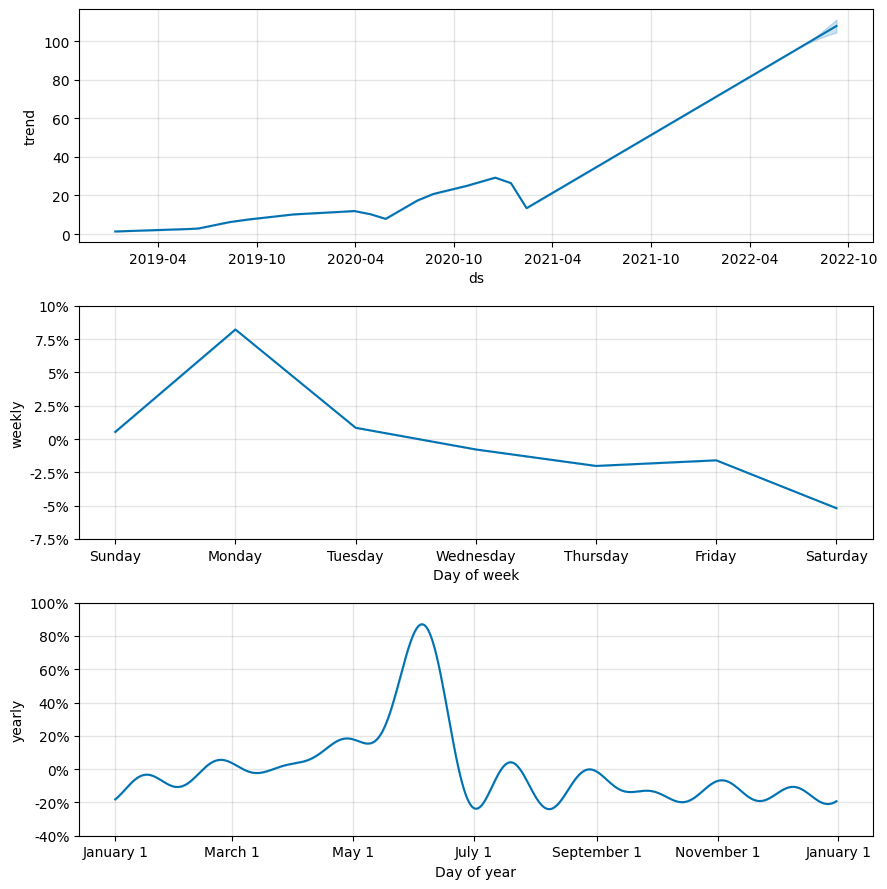

In [ ]:
fig_components = model.plot_components(forecast); # Gráfica de componentes. Uso un punto y coma (;) para que solo se muestre la gráfica una vez.

#**MAPE**

In [ ]:
get_MAPE(real_df = data_model, forecasted_df =forecast, real_time_column_name = "ds", real_y_column_name = "y") # Mi propia función MAPE

{'MAPE': 31.163244344057766,
 'False_counter': 0,
 'zero_counter': 0,
 'Mensaje de error': 'No se encontraron errores.'}

In [ ]:
mape_value = MAPE(data_model["y"], forecast.iloc[:-90]["yhat"]) * 100 # Función mean_absolute_percentage_error (MAPE) de sklearn
mape_value

31.163244344057816

#**Descarga de datos de Google Colab**

In [ ]:
forecast.to_csv("forecast.csv")
files.download("forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Inteligencia de negocio**

**Identificación de patrones**


*   **Tendencia:** La tendencia es positiva, pero se muestran caidas en la tendencia a lo largo de la serie de tiempo. Sin embargo, el alza en la tendecia es pronunciada a inicios del 2022 (entre enero y febrero).
*   **Temporalidad:** La demanda tienen una temporalidad semanal. Se observa que las ventas por procesar, tanto en monto como en cantidad, aumentan los lunes.
*   **Anomalias:** Se observa que en los primeros días de junio de 2022 la cantidad de órdenes de venta y el importe aumentan significativamente. El 12 de junio de 2022 hay una caida significativa en las ventas, sin embargo, la información no es del día completo, ya que el último dato es de las 18h.

<br>

**Precisión del pronóstico** <br>
El pronóstico realizado con Prophet se muestra relativamente similar a la cantidad real.<br>
El MAPE varía según el tipo de datos utilizados para el *forecast*:
*   **Importe total de ventas por día:** $50.57$
*   **Cantidad total de órdenes por día:** $31.16$

Utilizando la cantidad total de órdenes por día se obtiene un pronóstico más exacto.

<br>

**Recomendaciones y conclusiones**
1.   Las órdenes analizadas se encuentran con el estatus «Procesando». La cantidad de órdenes con este estatus tiende a disminuir conforme terminan de ser procesadas. Es por eso que la cantidad de órdenes es mayor a finales de la serie de tiempo en comparación con el inicio.
2.   Después del pico de demanda experimentado entre el 3 al 6 de junio de 2025 la demanda comienza a regularizarse.
3.   Sin embargo, debido a la tendencia a la alta a lo largo de la serie de tiempo, se recomienda que le empresa de *e-commerce* se prepare con el fin de mantener niveles de inventario y recursos humanos suficientes a un largo plazo.

